## Modelo de classificação: prever se o voo vai atrasar

Objetivo: **classificação binária** — prever se um voo terá **atraso na chegada** (target: atraso > 15 min, padrão FAA) usando apenas informações disponíveis **antes** do voo (data, horário programado, companhia, origem, destino, distância).

- Dados: `flights.csv`, `airlines.csv`, `airports.csv`
- Target: `atrasado = 1` se `ARRIVAL_DELAY > 15`, senão `0`
- Excluímos voos cancelados e desviados

In [2]:
from __future__ import annotations

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
np.random.seed(42)

### Carregar dados e funções de limpeza (reutilizadas do EDA)

In [3]:
CANDIDATE_DIRS = [Path("."), Path("data")]


def pick_path(filename: str) -> Path:
    for d in CANDIDATE_DIRS:
        p = d / filename
        if p.exists():
            return p
    return CANDIDATE_DIRS[0] / filename


FLIGHTS_PATH = pick_path("flights.csv")
AIRPORTS_PATH = pick_path("airports.csv")
AIRLINES_PATH = pick_path("airlines.csv")
assert FLIGHTS_PATH.exists(), f"Arquivo não encontrado: {FLIGHTS_PATH.resolve()}"

DELAY_CAUSE_COLS = [
    "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY",
]


def hhmm_to_minutes(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    s = str(x).strip().zfill(4)
    if not s.isdigit() or len(s) != 4:
        return np.nan
    hh, mm = int(s[:2]), int(s[2:])
    if not (0 <= hh <= 23 and 0 <= mm <= 59):
        return np.nan
    return hh * 60 + mm


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["scheduled_dep_min"] = df["SCHEDULED_DEPARTURE"].map(hhmm_to_minutes)
    df["scheduled_dep_hour"] = (df["scheduled_dep_min"] // 60).astype("Int64")
    df["scheduled_arr_min"] = df["SCHEDULED_ARRIVAL"].map(hhmm_to_minutes)
    df["scheduled_arr_hour"] = (df["scheduled_arr_min"] // 60).astype("Int64")
    return df


def clean_flights(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    obj_cols = df.select_dtypes(include=["object", "string"]).columns
    if len(obj_cols):
        df[obj_cols] = df[obj_cols].replace({"": pd.NA})
    for c in ["CANCELLED", "DIVERTED"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype("Int8")
    not_cancelled = (df["CANCELLED"] == 0) if "CANCELLED" in df.columns else pd.Series(True, index=df.index)
    present_delay = [c for c in DELAY_CAUSE_COLS if c in df.columns]
    if present_delay:
        df.loc[not_cancelled, present_delay] = df.loc[not_cancelled, present_delay].apply(pd.to_numeric, errors="coerce").fillna(0)
    if "CANCELLATION_REASON" in df.columns and "CANCELLED" in df.columns:
        df.loc[not_cancelled & df["CANCELLATION_REASON"].isna(), "CANCELLATION_REASON"] = "NOT_CANCELLED"
        df.loc[(~not_cancelled) & df["CANCELLATION_REASON"].isna(), "CANCELLATION_REASON"] = "UNKNOWN"
    num_like = ["YEAR", "MONTH", "DAY", "DAY_OF_WEEK", "DISTANCE", "DEPARTURE_DELAY", "ARRIVAL_DELAY", "TAXI_OUT", "TAXI_IN", "AIR_TIME", "ELAPSED_TIME", "SCHEDULED_TIME"]
    for c in [x for x in num_like if x in df.columns]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    if all(c in df.columns for c in ["YEAR", "MONTH", "DAY"]):
        df["date"] = pd.to_datetime({"year": df["YEAR"], "month": df["MONTH"], "day": df["DAY"]}, errors="coerce")
    return add_time_features(df)


def load_sample(path: Path, chunksize=250_000, frac_per_chunk=0.03, max_rows=400_000, seed=42):
    rng = np.random.default_rng(seed)
    samples = []
    for chunk in pd.read_csv(path, chunksize=chunksize):
        s = chunk.sample(frac=frac_per_chunk, random_state=int(rng.integers(0, 2**31 - 1)))
        samples.append(s)
        if sum(len(x) for x in samples) >= max_rows:
            break
    df = pd.concat(samples, ignore_index=True)
    if len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=seed).reset_index(drop=True)
    return clean_flights(df)


df = load_sample(FLIGHTS_PATH)
print("Shape:", df.shape)

Shape: (174572, 36)


### Definir target e filtrar dados para classificação

In [4]:
# Só voos realizados (não cancelados, não desviados)
mask_ok = (df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)
df_ok = df.loc[mask_ok].copy()

# Target: atraso na chegada > 15 minutos (padrão FAA "atrasado")
MIN_DELAY_MINUTES = 15
df_ok["atrasado"] = (df_ok["ARRIVAL_DELAY"] > MIN_DELAY_MINUTES).astype(int)

# Remover linhas onde ARRIVAL_DELAY é NaN (não dá para definir target)
df_ok = df_ok.dropna(subset=["ARRIVAL_DELAY", "atrasado"])

print("Proporção de voos atrasados (target=1):", round(float(df_ok["atrasado"].mean()), 3))
print("Contagem:", df_ok["atrasado"].value_counts().to_dict())

Proporção de voos atrasados (target=1): 0.18
Contagem: {0: 140625, 1: 30768}


### Features disponíveis *antes* do voo (sem usar atraso real)

In [5]:
FEATURES_CAT = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
FEATURES_NUM = ["MONTH", "DAY", "DAY_OF_WEEK", "scheduled_dep_hour", "DISTANCE", "SCHEDULED_TIME"]
TARGET = "atrasado"

all_feature_cols = FEATURES_CAT + FEATURES_NUM
for c in all_feature_cols:
    if c not in df_ok.columns:
        raise ValueError(f"Coluna ausente: {c}")

# Remover linhas com NaN nas features (para treino estável)
df_model = df_ok.dropna(subset=all_feature_cols + [TARGET]).copy()
# OneHotEncoder exige tipo uniforme: garantir que categóricas sejam string (evita int/str misto)
for c in FEATURES_CAT:
    df_model[c] = df_model[c].astype(str)
X = df_model[all_feature_cols]
y = df_model[TARGET]

print("Amostras para treino:", len(X))
print("Features:", all_feature_cols)

Amostras para treino: 171393
Features: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'scheduled_dep_hour', 'DISTANCE', 'SCHEDULED_TIME']


### Pipeline: codificação + modelo

In [6]:
preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), FEATURES_CAT),
        ("num", StandardScaler(), FEATURES_NUM),
    ],
    remainder="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Random Forest
model_rf = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42))])
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Acurácia:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf, zero_division=0), 4))
print("F1:", round(f1_score(y_test, y_pred_rf, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))

=== Random Forest ===
Acurácia: 0.8205
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.6465


In [7]:
# Regressão Logística (comparação)
model_lr = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=500, random_state=42))])
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

print("=== Regressão Logística ===")
print("Acurácia:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr, zero_division=0), 4))
print("F1:", round(f1_score(y_test, y_pred_lr, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 4))

=== Regressão Logística ===
Acurácia: 0.8205
Precision: 0.4857
Recall: 0.0022
F1: 0.0044
ROC-AUC: 0.6328


### Matriz de confusão (Random Forest)

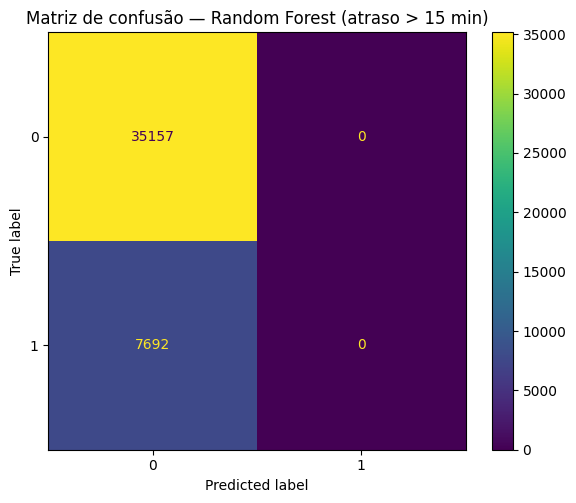

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, colorbar=True)
ax.set_title("Matriz de confusão — Random Forest (atraso > 15 min)")
plt.tight_layout()
plt.show()

### Validação cruzada (RF)

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model_rf, X, y, cv=cv, scoring="roc_auc")
print("ROC-AUC (CV 5-fold):", [round(s, 4) for s in scores])
print("Média:", round(float(scores.mean()), 4), "±", round(float(scores.std()), 4))

ROC-AUC (CV 5-fold): [np.float64(0.6528), np.float64(0.6418), np.float64(0.6574), np.float64(0.643), np.float64(0.6432)]
Média: 0.6477 ± 0.0063


In [10]:
# Listar voos previstos como atrasados no conjunto de teste

df_test = df_model.loc[X_test.index].copy()
df_test["y_true"] = y_test.values
df_test["y_pred"] = y_pred_rf
df_test["proba_delay"] = y_proba_rf

voos_previstos_atrasados = (
    df_test[df_test["y_pred"] == 1]
    .sort_values("proba_delay", ascending=False)
)

voos_previstos_atrasados.head(20)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,date,scheduled_dep_min,scheduled_dep_hour,scheduled_arr_min,scheduled_arr_hour,atrasado,y_true,y_pred,proba_delay


In [11]:
# Veja os 20 voos com maior probabilidade prevista de atraso
top_atrasos = (
    df_test
    .sort_values("proba_delay", ascending=False)
    .head(20)
)

top_atrasos[
    ["YEAR", "MONTH", "DAY", "AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT",
     "SCHEDULED_DEPARTURE", "DISTANCE", "y_true", "proba_delay"]
]

,YEAR,MONTH,DAY,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE,y_true,proba_delay
72101,2015,5,28,NK,IAH,ORD,1839,925,0,0.289033
76582,2015,6,21,NK,IAH,ORD,1839,925,0,0.287135
27151,2015,2,23,MQ,DBQ,ORD,1655,147,1,0.275355
62327,2015,5,20,F9,PHL,ORD,1810,678,1,0.270390
16026,2015,2,8,NK,IAH,ORD,615,925,0,0.270311
102484,2015,7,27,MQ,DBQ,ORD,1645,147,0,0.270133
54992,2015,5,7,NK,IAH,ORD,605,925,0,0.269603
40282,2015,4,3,F9,ATL,CLE,1910,554,1,0.267434
35831,2015,3,19,NK,DEN,DFW,2055,641,1,0.266583
4440,2015,1,2,NK,LGA,ORD,2155,733,0,0.266320
